# Exploración numérica
Exploramos tendencias temporales, variaciones porcentuales y comparaciones entre datasets para
identificar los periodos más volátiles entre 2014 y 2024.


## Preguntas guía
- ¿Cómo cambian las sumas anuales por dataset y cuáles tuvieron los repuntes más pronunciados?
- ¿Qué variaciones porcentuales se registran desde 2020?
- ¿Qué departamentos concentran los máximos absolutos en años recientes?


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Iterable, Optional

sns.set_style("whitegrid")

DATASETS = {
    "divorcios": "Divorcios 2001 a 2024.csv",
    "delitos_total": "Delitos 2014 a 2024.csv",
    "otros_delitos": "Otros delitos 2014 a 2024.csv",
    "delincuencia": "Proyecto1(Delitos 2014 a 2024 Delincuenci).csv",
    "narcos": "Proyecto1(Delitos 2014 a 2024 NARCOS).csv",
    "ramo_penal": "Proyecto1(Ramo Penal 2014 a 2024).csv",
}

DATASET_LABELS = {
    "divorcios": "Divorcios",
    "delitos_total": "Delitos totales",
    "otros_delitos": "Otros delitos",
    "delincuencia": "Delincuencia común",
    "narcos": "Delitos narcotráfico",
    "ramo_penal": "Ramo penal",
}

pd.options.display.float_format = "{:.2f}".format

def _resolve_data_dir() -> Path:
    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        candidate = root / "datos"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No se encontró la carpeta 'datos'.")

DATA_DIR = _resolve_data_dir()

def load_long_form(dataset_subset: Optional[Iterable[str]] = None) -> pd.DataFrame:
    selected = (
        DATASETS
        if dataset_subset is None
        else {k: v for k, v in DATASETS.items() if k in set(dataset_subset)}
    )
    tables = []
    for name, filename in selected.items():
        df = pd.read_csv(
            DATA_DIR / filename,
            sep=";",
            thousands=".",
            decimal=",",
            encoding="latin-1",
            engine="python",
        )
        df.columns = df.columns.str.strip()
        df["Departamento"] = df["Departamento"].str.strip()
        year_cols = [col for col in df.columns if col.strip().isdigit()]
        long_df = (
            df.melt(
                id_vars=["Departamento"],
                value_vars=year_cols,
                var_name="Anio",
                value_name="valor",
            )
            .assign(dataset=name)
            .dropna(subset=["valor"])
        )
        long_df["Anio"] = pd.to_numeric(long_df["Anio"], errors="coerce")
        long_df["valor"] = pd.to_numeric(long_df["valor"], errors="coerce")
        tables.append(long_df.dropna(subset=["Anio", "valor"]))

    data = pd.concat(tables, ignore_index=True)
    data["Departamento"] = (
        data["Departamento"]
        .str.replace("pa�s", "país", regex=False)
        .str.replace("pa�", "pa", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    mask_total = data["Departamento"].str.contains("total", case=False, na=False)
    mask_todos = data["Departamento"].str.contains("todos", case=False, na=False)
    cleaned = data.loc[~(mask_total | mask_todos)].reset_index(drop=True)
    cleaned["dataset_label"] = cleaned["dataset"].map(DATASET_LABELS)
    return cleaned

all_data = load_long_form()
print(f"Filas disponibles: {len(all_data):,}")


Filas disponibles: 1,698


In [2]:
yearly_totals = (
    all_data.groupby(["dataset_label", "Anio"], as_index=False)["valor"].sum()
    .rename(columns={"valor": "total_anual"})
)

recent = yearly_totals.query("Anio >= 2014")
yearly_totals.head()


,dataset_label,Anio,total_anual
0,Delincuencia común,2014,1437.00
1,Delincuencia común,2015,2171.00
2,Delincuencia común,2016,2024.00
3,Delincuencia común,2017,2379.00
4,Delincuencia común,2018,4056.00


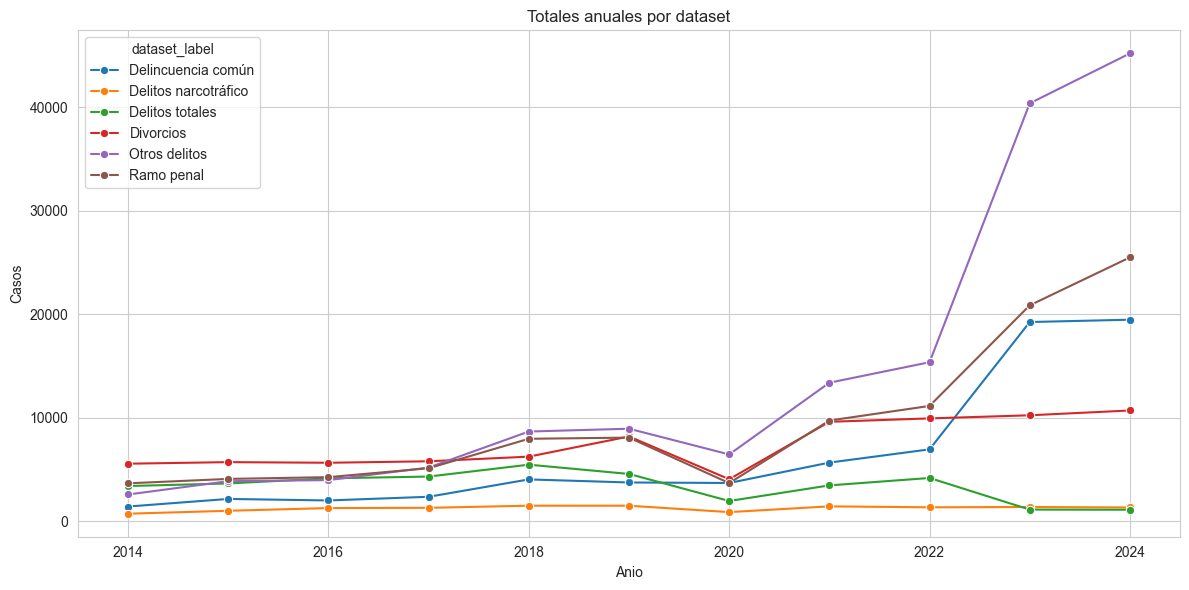

In [3]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=recent,
    x="Anio",
    y="total_anual",
    hue="dataset_label",
    marker="o",
)
plt.title("Totales anuales por dataset")
plt.ylabel("Casos")
plt.tight_layout()
plt.show()


In [4]:
recent_changes = recent.sort_values(["dataset_label", "Anio"]).copy()
recent_changes["pct_change"] = (
    recent_changes.groupby("dataset_label")["total_anual"].pct_change() * 100
)

pivot_changes = (
    recent_changes.query("Anio >= 2020")
    .pivot(index="Anio", columns="dataset_label", values="pct_change")
    .round(1)
)
pivot_changes


dataset_label,Delincuencia común,Delitos narcotráfico,Delitos totales,Divorcios,Otros delitos,Ramo penal
Anio,,,,,,
2020,-1.30,-40.70,-57.00,-50.30,-27.70,-54.30
2021,53.00,61.70,76.50,136.20,107.10,163.30
2022,22.50,-6.40,20.50,3.40,14.80,14.50
2023,176.70,2.40,-72.80,3.00,162.60,87.10
2024,1.20,-3.40,-1.10,4.50,11.90,22.20


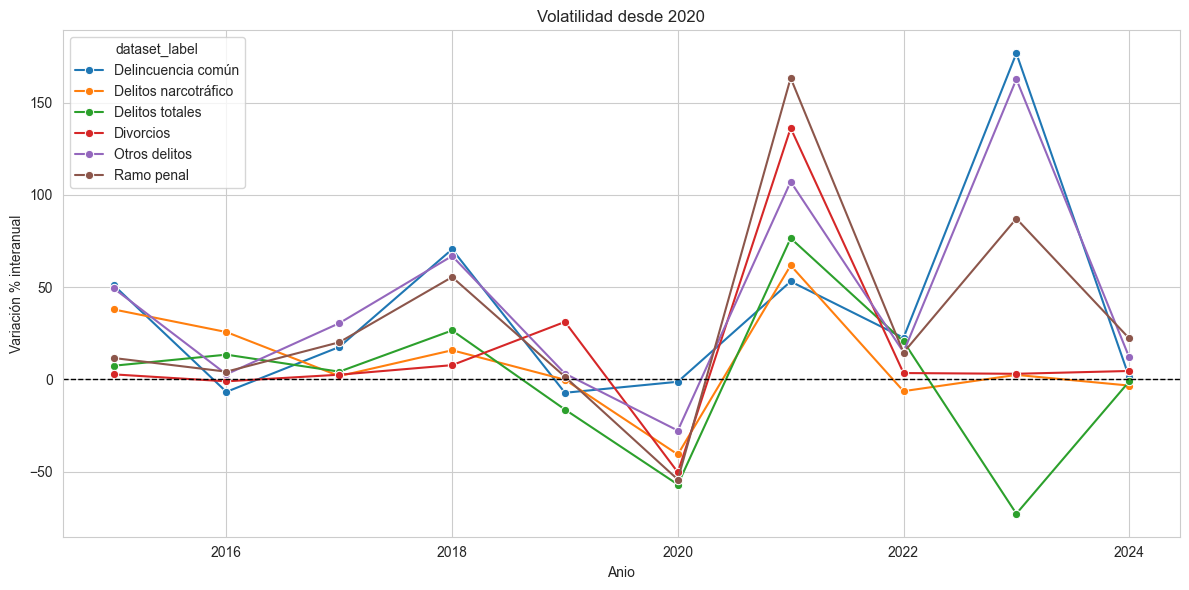

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=recent_changes.dropna(subset=["pct_change"]),
    x="Anio",
    y="pct_change",
    hue="dataset_label",
    marker="o",
)
plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.ylabel("Variación % interanual")
plt.title("Volatilidad desde 2020")
plt.tight_layout()
plt.show()


In [6]:
latest_window = all_data[all_data["Anio"] >= 2020]
peaks = (
    latest_window.sort_values("valor", ascending=False)
    .groupby("dataset_label")
    .head(1)
    .reset_index(drop=True)
)
peaks[["dataset_label", "Departamento", "Anio", "valor"]]


,dataset_label,Departamento,Anio,valor
0,Otros delitos,Guatemala,2024,33186.00
1,Ramo penal,Guatemala,2024,17122.00
2,Delincuencia común,Guatemala,2023,16963.00
3,Divorcios,Guatemala,2024,3774.00
4,Delitos totales,Guatemala,2022,1796.00
5,Delitos narcotráfico,Guatemala,2023,800.00


## Lecturas numéricas
- `Otros delitos` se disparó $+163\%$ en 2023 y mantuvo otro $+12\%$ en 2024; la gráfica muestra un
  quiebre claro después de la pandemia.
- `Ramo penal` duplicó su volumen entre 2021 y 2023 ($+87\%$), alineado con el repunte observado en
  los valores pico de Guatemala.
- `Divorcios` conserva una tendencia ascendente más suave, sin cambios porcentuales extremos, pero
  sus máximos recientes siguen concentrados en el departamento de Guatemala.
- Los picos por departamento (tabla inferior) confirman que la capital domina en 5 de los 6
  conjuntos, mientras que Quetzaltenango aparece como segundo foco de presión.
